# Supervised Classification

**Classification** refers to when we are interested in predicting a *discrete* or *categorical* label for each sample from a
set of input features. This page covers several core concepts related to classification that we discussed in the lecture:
- **logistic regression** (binary classification) 
- **softmax regression** (multi-class classification)
- the loss functions used to train classifiers
- how we evaluate a trained classifier

## Binary, multi-class, multi-label
We first make the distinction between binary classification, multi-class classification, and multi-label classification. In this lecture, we will focus on binary and multi-class classification.
- **Binary classification** — assign one of *two* mutually exclusive classes.
  *Is there currently a tornado? (true / false)*
- **Multi-class classification** — assign one of *three or more* mutually
  exclusive classes. *Which cloud type is this? Which land-use category?*
- **Multi-label classification** — assign several *non*-exclusive labels to each sample (e.g. an image can contain *both* clouds
  *and* snow).

## Notation

For a data set of $N_s$ samples, each with $m$ features:

- $X$ — the feature matrix, shape $N_s \times m$. Each **row** is a sample,
  each **column** is a feature.
- $Y$ — the ground-truth labels.
- A classifier learns a function $f$ that maps features to predicted labels:
  $\hat{Y} = f(X|w)$. $w$ refers to the weights of the machine learning model (which we learn through training on the training data set).


## Logistic Regression & the sigmoid function
The simplest supervised machine learning model that we can use for binary classification problems is logistic regression.  **Logistic regression** takes a linear combination of the features,

$$z = b + w_1 x_1 + w_2 x_2 + \dots + w_m x_m
    = \mathbf{w}\cdot\mathbf{x} + b$$

and squashes it through the **sigmoid** (logistic) function to get a probability between 0 and 1. 

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

$p = \sigma(z)$ is the predicted probability of the positive ("red") class;
$1-p$ is the probability of the other ("blue") class. We assume a threshold of $0.5$ (i.e. $z=0$) to assign the final label to any sample in our data set.

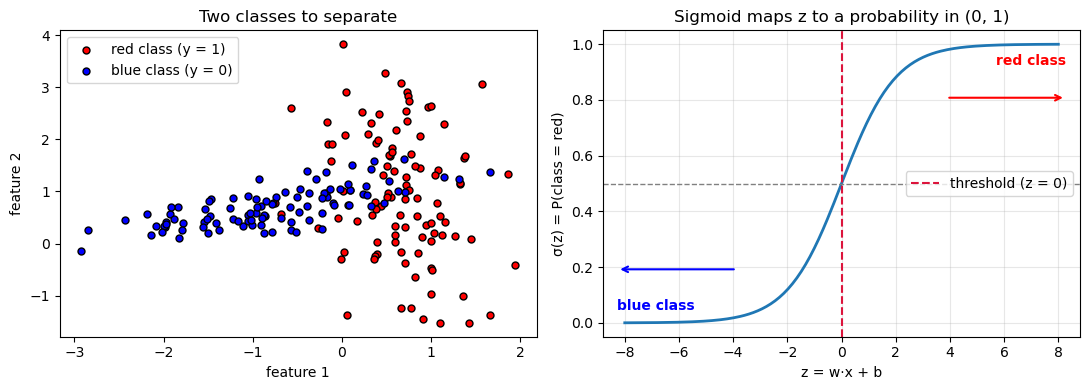

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# The same toy dataset used in the logistic-regression section below.
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, class_sep=0.7, random_state=0)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: what "red" and "blue" mean — the two classes we want to tell apart.
ax1.scatter(X[y == 1, 0], X[y == 1, 1], c="red",  edgecolor="k", s=25, label="red class (y = 1)")
ax1.scatter(X[y == 0, 0], X[y == 0, 1], c="blue", edgecolor="k", s=25, label="blue class (y = 0)")
ax1.set_xlabel("feature 1"); ax1.set_ylabel("feature 2")
ax1.set_title("Two classes to separate")
ax1.legend()

# Right: the sigmoid turns the score z into P(red).
z = np.linspace(-8, 8, 200)
ax2.plot(z, sigmoid(z), lw=2)
ax2.axhline(0.5, color="gray", ls="--", lw=1)
ax2.axvline(0, color="crimson", ls="--", lw=1.5, label="threshold (z = 0)")
ax2.annotate("red class", xy=(0.97, 0.9), xycoords="axes fraction",
             ha="right", va="center", color="red", fontweight="bold")
ax2.annotate("", xy=(0.97, 0.78), xytext=(0.72, 0.78), xycoords="axes fraction",
             arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
ax2.annotate("blue class", xy=(0.03, 0.1), xycoords="axes fraction",
             ha="left", va="center", color="blue", fontweight="bold")
ax2.annotate("", xy=(0.03, 0.22), xytext=(0.28, 0.22), xycoords="axes fraction",
             arrowprops=dict(arrowstyle="->", color="blue", lw=1.5))
ax2.set_xlabel("z = w·x + b")
ax2.set_ylabel("σ(z) = P(class = red)")
ax2.set_title("Sigmoid maps z to a probability in (0, 1)")
ax2.legend(loc="center right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Binary cross-entropy loss

We train logistic regression by minimizing the **binary cross-entropy** (also known as the log
loss). For a single sample with true label $y \in \{0, 1\}$ and predicted
probability $p$:

$$\mathcal{L} = -\big[\, y \log p + (1-y)\log(1-p) \,\big]$$

This loss is **small** when the model is confident and correct, and blows up
when the model is confident and *wrong* — that steep penalty is what makes binary cross entropy a good loss function for logistic regression, as it more useful than simply counting mistakes. To determine the total loss of our classifier, we sum over the loss of all of the individual samples in our training data set.

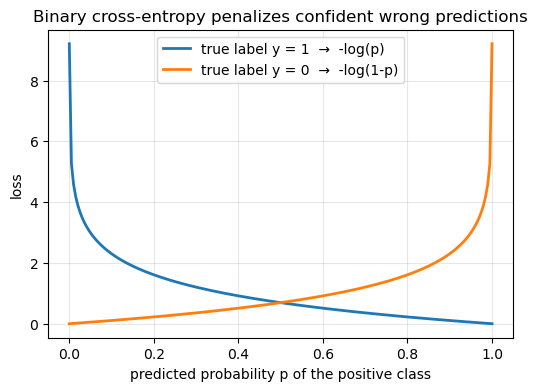

In [2]:
p = np.linspace(1e-4, 1 - 1e-4, 200)
plt.figure(figsize=(6, 4))
plt.plot(p, -np.log(p), lw=2, label="true label y = 1  →  -log(p)")
plt.plot(p, -np.log(1 - p), lw=2, label="true label y = 0  →  -log(1-p)")
plt.xlabel("predicted probability p of the positive class")
plt.ylabel("loss")
plt.title("Binary cross-entropy penalizes confident wrong predictions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Logistic regression: a learned decision boundary

Because the boundary $z = \mathbf{w}\cdot\mathbf{x} + b = 0$ is linear,
logistic regression separates the classes with a straight line (a hyperplane in
higher dimensions). The color below shows the predicted probability. Note how
it grades smoothly from one class to the other across the decision boundary.

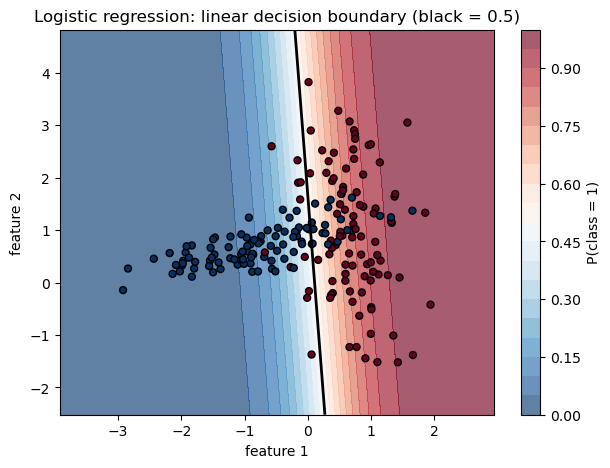

In [3]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, class_sep=0.7, random_state=0)
clf = LogisticRegression().fit(X, y)

# probability surface
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 300),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 300))
prob = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(7, 5))
cs = plt.contourf(xx, yy, prob, levels=20, cmap="RdBu_r", alpha=0.65)
plt.colorbar(cs, label="P(class = 1)")
plt.contour(xx, yy, prob, levels=[0.5], colors="k", linewidths=2)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolor="k", s=25)
plt.title("Logistic regression: linear decision boundary (black = 0.5)")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.show()

## Softmax regression for multi-class problems

**Softmax regression** generalizes logistic regression to $K$ mutually
exclusive classes. Each class $k$ gets its own score
$z_k = \mathbf{w}_k\cdot\mathbf{x} + b_k$, and the **softmax** function turns
the scores into a probability distribution that sums to 1:

$$p_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

The predicted class is the one with the highest probability. 

Some environmental applications of multi-class classification include land-cover or land usage classification using satellite images, cloud-type classification, ice-crystal morphology classification, and aurora classification.

Below we fit softmax regression to the three-class Iris data set from the ``scikit-learn`` library (using two
features so we can draw the decision boundaries). The Iris data sets consists of 3 different classes of irises (Setosa, Versicolor, and Virginica), and measurements of their sepal length, sepal width, petal length and petal width, stored in a 150x4 ``numpy.ndarray``

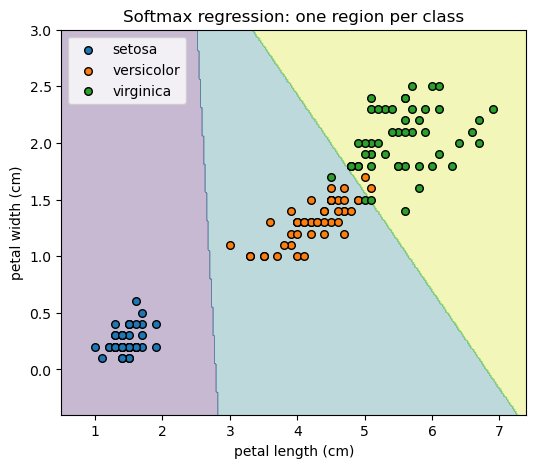

In [4]:
from sklearn.datasets import load_iris

iris = load_iris()
Xi = iris.data[:, 2:4]      # petal length, petal width
yi = iris.target
soft = LogisticRegression(max_iter=1000).fit(Xi, yi)

xx, yy = np.meshgrid(np.linspace(Xi[:, 0].min()-0.5, Xi[:, 0].max()+0.5, 300),
                     np.linspace(Xi[:, 1].min()-0.5, Xi[:, 1].max()+0.5, 300))
Z = soft.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
for k, name in enumerate(iris.target_names):
    plt.scatter(Xi[yi == k, 0], Xi[yi == k, 1], label=name, edgecolor="k", s=30)
plt.xlabel("petal length (cm)"); plt.ylabel("petal width (cm)")
plt.title("Softmax regression: one region per class")
plt.legend()
plt.show()

## Training: gradient descent

Both models minimize their loss with **gradient descent** — iteratively nudging
the weights $\mathbf{w}$ in the direction that reduces the loss. In practice we
use **mini-batch stochastic gradient descent**: we update the weights using small
random batches of samples, which is more memory-efficient. The logistic and softmax losses are convex
(they have a single global minimum), so here the stochastic noise matters less than
it does for non-convex models such as neural networks.

- **Batch GD** — use all samples for each update (accurate, slow).
- **Stochastic GD** — one sample per update (noisy, fast).
- **Mini-batch GD** — a small batch per update (the practical middle ground).

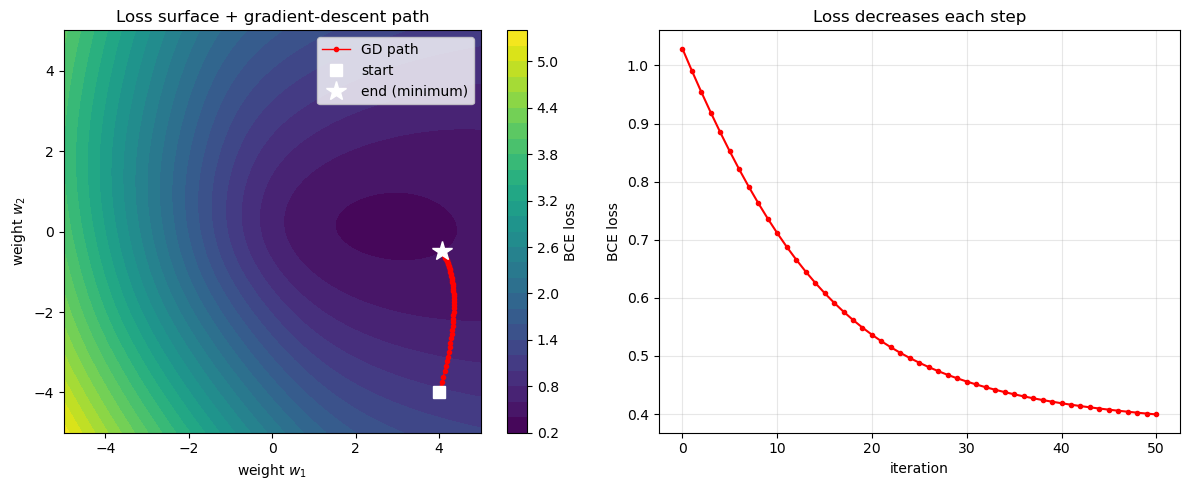

In [5]:
# Visualize gradient descent on the binary cross-entropy loss surface.
# We reuse the two-feature dataset (X, y) from the logistic-regression section.
Xs = (X - X.mean(0)) / X.std(0)   # standardize so a bias-free model works well

def bce(w):
    p = sigmoid(Xs @ w)
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def grad(w):
    return Xs.T @ (sigmoid(Xs @ w) - y) / len(y)

# Run gradient descent, recording the weight path and loss at each step.
w = np.array([4.0, -4.0])        # deliberately poor starting point
lr, path = 0.5, [w.copy()]
for _ in range(50):
    w = w - lr * grad(w)
    path.append(w.copy())
path = np.array(path)
losses = [bce(wi) for wi in path]

# Loss surface over a grid of the two weights.
w1 = np.linspace(-5, 5, 200)
w2 = np.linspace(-5, 5, 200)
W1, W2 = np.meshgrid(w1, w2)
L = np.array([[bce(np.array([a, b])) for a in w1] for b in w2])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cs = ax1.contourf(W1, W2, L, levels=30, cmap="viridis")
fig.colorbar(cs, ax=ax1, label="BCE loss")
ax1.plot(path[:, 0], path[:, 1], "o-", color="red", ms=3, lw=1, label="GD path")
ax1.plot(*path[0], "ws", ms=9, label="start")
ax1.plot(*path[-1], "w*", ms=15, label="end (minimum)")
ax1.set_xlabel("weight $w_1$"); ax1.set_ylabel("weight $w_2$")
ax1.set_title("Loss surface + gradient-descent path")
ax1.legend(loc="upper right")

ax2.plot(losses, "o-", color="red", ms=3)
ax2.set_xlabel("iteration"); ax2.set_ylabel("BCE loss")
ax2.set_title("Loss decreases each step")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluating a classifier

### Confusion matrix

One way that we can evaluate how well a trained classifier is doing is by looking at its **confusion matrix**. The **confusion matrix** counts true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN) associated with each class. It reveals *which* classes get confused.

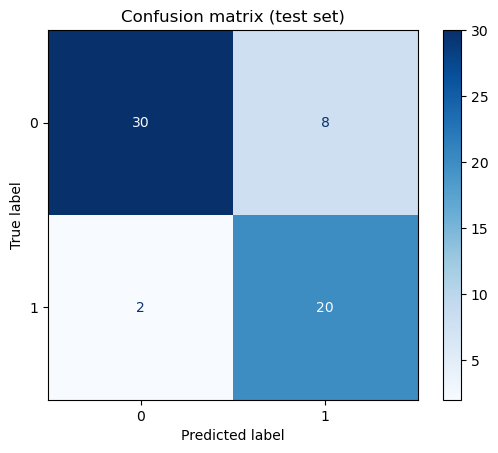

              precision    recall  f1-score   support

           0       0.94      0.79      0.86        38
           1       0.71      0.91      0.80        22

    accuracy                           0.83        60
   macro avg       0.83      0.85      0.83        60
weighted avg       0.86      0.83      0.84        60



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
clf = LogisticRegression().fit(Xtr, ytr)
ConfusionMatrixDisplay.from_estimator(clf, Xte, yte, cmap="Blues")
plt.title("Confusion matrix (test set)")
plt.show()

print(classification_report(yte, clf.predict(Xte)))

### Accuracy, precision, recall, F1

Some other metrics that can be used to describe how well a classifier fits the data are defined below:

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}
\qquad
\text{Precision} = \frac{TP}{TP+FP}
\qquad
\text{Recall} = \frac{TP}{TP+FN}$$

- **Precision** — of everything we *predicted* positive, how much really is?
  (Penalizes false positives.)
- **Recall (sensitivity)** — of all the *actual* positives, how many did we
  catch? (Penalizes false negatives.)
- **F1 score** — the harmonic mean of precision and recall, useful when both
  error types matter or the classes are imbalanced:
  $F_1 = 2\cdot\frac{\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}$

### Precision vs. recall — a domain choice

The threshold you pick in defining how to separate classes can trade off between precision and recall. If we want to correctly identify more positive cases (in order to increase recall), our model will become less selective, leading to more false alarms (decreasing precision). Depending on what problem we are trying to solve, we may favor a classifier with either high recall or high precision,

- **Favor high recall** when a *miss* is costly. For example, if we are interested in forecasting a dangerous storms or a flash flood, a few false alarms are acceptable if we catch (almost) every real case.
- **Favor high precision** when a *false alarm* is costly. Mapping mountain permafrost, or drilling for oil — if the model says "positive," we want it to really be there before taking an action that might be costly.

### ROC curve and AUC

The **Receiver Operating Characteristic (ROC)** curve sweeps the classification
threshold and plots the true-positive rate against the false-positive rate. A
perfect classifier hugs the top-left corner; the diagonal is a "no-skill"
random guess. The **area under the curve (AUC)** summarizes overall performance
in a single number (0.5 = random, 1.0 = perfect). The curves below show
several classifiers of increasing skill, all falling between the no-skill
diagonal and the perfect corner.

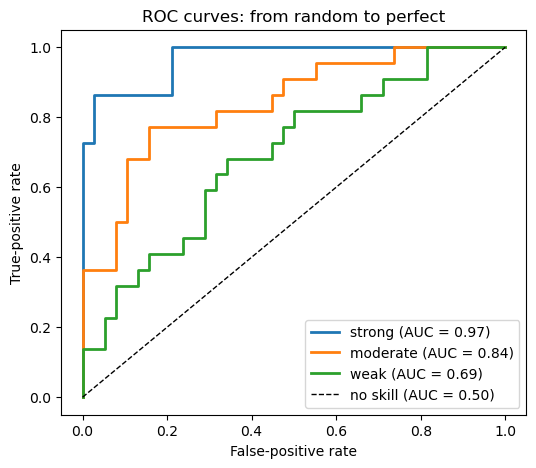

In [7]:
from sklearn.metrics import roc_curve, auc

# The trained model's own scores on the test set.
scores = clf.predict_proba(Xte)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
rng = np.random.default_rng(0)
noise = rng.random(len(scores))
for w, label in [(1.0, "strong"), (0.4, "moderate"), (0.2, "weak")]:
    blended = w * scores + (1 - w) * noise
    fpr, tpr, _ = roc_curve(yte, blended)
    ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC = {auc(fpr, tpr):.2f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="no skill (AUC = 0.50)")

ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.set_title("ROC curves: from random to perfect")
ax.legend(loc="lower right")
plt.show()

## Summary

This page covered the core building blocks of **supervised classification** —
predicting a discrete label from a set of input features.

- **Logistic regression** computes a linear score $z = \mathbf{w}\cdot\mathbf{x} + b$
  and passes it through the **sigmoid** to get $p = \sigma(z)$, the probability
  of the positive class. Comparing $p$ to a **threshold** (0.5 by default, i.e.
  $z = 0$) produces the final label. The decision boundary is *linear*: a
  straight line in 2-D, a hyperplane in higher dimensions.
- We train it by **minimizing the binary cross-entropy loss**, which rewards
  confident correct predictions and heavily penalizes confident wrong ones.
- **Softmax (multinomial) regression** generalizes logistic regression to $K$
  mutually exclusive classes: it produces one score per class and normalizes
  them with the softmax so the probabilities are non-negative and sum to 1. The
  predicted class is the one with the highest probability.
- Both models are fit by **gradient descent** (batch, stochastic, or
  mini-batch). Because their losses are convex, gradient descent reliably finds
  the single global minimum.
- **Evaluating a classifier** goes well beyond simply evaluating its accuracy, which can be misleading
  on imbalanced data:
  - The **confusion matrix** breaks predictions into true/false positives and
    negatives, showing *which* classes get confused.
  - **Precision** ("of the positives I predicted, how many were right?") and
    **recall** ("of the actual positives, how many did I catch?") trade off
    against each other; the **F1 score** is their harmonic mean.
  - The **ROC curve** sweeps the threshold and plots true-positive vs.
    false-positive rate; the **AUC** summarizes it in a single threshold-free
    number (0.5 = random, 1.0 = perfect).
- Which metric matters depends on the **cost of each error type** in your
  problem. A missed wildfire detection and a false alarm are not equally
  expensive, so choose the operating threshold accordingly rather than
  defaulting to 0.5.